<a href="https://colab.research.google.com/github/Ji2424/Deep-Learning-Based-Segmentation-of-the-Stratum-Corneum-in-OCT-Images/blob/main/u_net%2B%2B.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
#  OCT Skin Layer Segmentation - U-Net (Google Colab)
# ============================================================

In [ ]:
# CELL 1 - Install dependencies
!pip install segmentation-models-pytorch albumentations -q

In [ ]:
from google.colab import drive
import os

# Mount the drive
drive.mount('/content/drive')

# --- DIRECTORY SETUP ---
# Based on your description of the larger dataset
BASE_PATH = '/content/drive/MyDrive/new_2'
IMG_DIR = os.path.join(BASE_PATH, 'images_2')
MASK_DIR = os.path.join(BASE_PATH, 'masks_2')

# Quick sanity check
if os.path.exists(IMG_DIR) and os.path.exists(MASK_DIR):
    img_list = sorted(os.listdir(IMG_DIR))
    mask_list = sorted(os.listdir(MASK_DIR))
    print(f"✅ Success! Large Dataset Loaded.")
    print(f"📸 Images found: {len(img_list)}")
    print(f"🎭 Masks found: {len(mask_list)}")

    # Crucial: Check if counts match
    if len(img_list) != len(mask_list):
        print("⚠️ Warning: Image and Mask counts do not match!")
else:
    print("❌ Error: Paths not found. Double check folder names in Drive.")

Mounted at /content/drive
✅ Success! Large Dataset Loaded.
📸 Images found: 1272
🎭 Masks found: 1272


In [ ]:
# CELL 3 - Imports

import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import cv2

from sklearn.model_selection import train_test_split

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.optim.lr_scheduler import StepLR

In [ ]:
# CELL 4 - MATCHING LOGIC
import os

# Get all filenames
all_imgs = os.listdir(IMG_DIR)
all_masks = os.listdir(MASK_DIR)

# Function to extract the common ID (e.g., 'img_1' from 'img_1.png')
# Adjust the split character if your names use something other than '_'
def get_id(fname):
    return fname.split('.')[0].replace('mask', '').replace('img', '')

# Create dictionaries for fast lookup
img_dict = {get_id(f): f for f in all_imgs if f.lower().endswith(('.png', '.jpg', '.jpeg'))}
mask_dict = {get_id(f): f for f in all_masks if f.lower().endswith(('.png', '.jpg', '.jpeg'))}

# Find intersection (IDs present in both)
common_ids = sorted(list(set(img_dict.keys()) & set(mask_dict.keys())))

# Build final lists
img_paths = [os.path.join(IMG_DIR, img_dict[id]) for id in common_ids]
mask_paths = [os.path.join(MASK_DIR, mask_dict[id]) for id in common_ids]

print(f"📊 Dataset Status:")
print(f"- Raw Images: {len(all_imgs)}")
print(f"- Raw Masks:  {len(all_masks)}")
print(f"- Matched Pairs for Training: {len(img_paths)} ✅")

# Quick verification of the first pair
if len(img_paths) > 0:
    print(f"\nFirst pair verification:")
    print(f"Image: {os.path.basename(img_paths[0])}")
    print(f"Mask:  {os.path.basename(mask_paths[0])}")

📊 Dataset Status:
- Raw Images: 1272
- Raw Masks:  1272
- Matched Pairs for Training: 1272 ✅

First pair verification:
Image: img_0001.png
Mask:  mask_0001.png


In [ ]:
# CELL 5 - BACK TO DRIVE PATHS
import cv2
import torch
import numpy as np
import os
import glob
from torch.utils.data import Dataset

# YOUR ACTUAL DRIVE PATHS
DRIVE_IMAGES = '/content/drive/MyDrive/new_2/images_2'
DRIVE_MASKS = '/content/drive/MyDrive/new_2/masks_2'

class SkinDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.img_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE)

        # Ensure mask matches image size exactly
        if img.shape[:2] != mask.shape[:2]:
            mask = cv2.resize(mask, (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

        # Standardizing mask values (adjust if your masks are already 0-3)
        mask = mask.astype(np.int64) - 1

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img = augmented['image']
            mask = augmented['mask']
        else:
            img = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
            mask = torch.from_numpy(mask).long()

        return img, mask

# Get the files directly from Drive
all_img_paths = sorted(glob.glob(os.path.join(DRIVE_IMAGES, '*')))
all_mask_paths = sorted(glob.glob(os.path.join(DRIVE_MASKS, '*')))

print(f"Found {len(all_img_paths)} images and {len(all_mask_paths)} masks in Drive.")

Found 1272 images and 1272 masks in Drive.


In [ ]:
# CELL 6 - SAFE PAIRING CHECK (DRIVE VERSION)
import os

# Ensure the script knows where to look in your Drive
IMAGES_DIR = '/content/drive/MyDrive/new_2/images_2'
MASKS_DIR = '/content/drive/MyDrive/new_2/masks_2'

# 1. Get files and filter out system junk
img_files = sorted([f for f in os.listdir(IMAGES_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
mask_files = sorted([f for f in os.listdir(MASKS_DIR) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

print(f"Total files found in Drive -> Images: {len(img_files)}, Masks: {len(mask_files)}")

# 2. Extract ID function to match "img_01.png" with "mask_01.png"
def extract_id(filename):
    # This grabs only the numbers from the filename
    return "".join(filter(str.isdigit, filename))

mask_dict = {extract_id(f): f for f in mask_files}

paired_imgs = []
paired_masks = []

# 3. Match them up
for img in img_files:
    img_id = extract_id(img)
    if img_id in mask_dict:
        paired_imgs.append(os.path.join(IMAGES_DIR, img))
        paired_masks.append(os.path.join(MASKS_DIR, mask_dict[img_id]))

img_paths = paired_imgs
mask_paths = paired_masks

print("Successfully paired samples:", len(img_paths))

# 4. Final check
if len(img_paths) > 0:
    print("\nVerification of first 3 pairs:")
    for i in range(min(3, len(img_paths))):
        print(f"✅ {os.path.basename(img_paths[i])} <---> {os.path.basename(mask_paths[i])}")
else:
    print("❌ ERROR: No pairs found. Check if image/mask filenames share the same numbers.")

assert len(img_paths) == len(mask_paths) and len(img_paths) > 0, "Mismatch or zero samples found!"

Total files found in Drive -> Images: 1272, Masks: 1272
Successfully paired samples: 1272

Verification of first 3 pairs:
✅ img_0001.png <---> mask_0001.png
✅ img_0002.png <---> mask_0002.png
✅ img_0003.png <---> mask_0003.png


In [ ]:
# CELL 6b - TRAIN/VAL/TEST SPLIT

img_train, img_temp, mask_train, mask_temp = train_test_split(
    img_paths, mask_paths, test_size=0.30, random_state=0)

img_val, img_test, mask_val, mask_test = train_test_split(
    img_temp, mask_temp, test_size=0.50, random_state=0)

print(len(img_train), len(img_val), len(img_test))

890 191 191


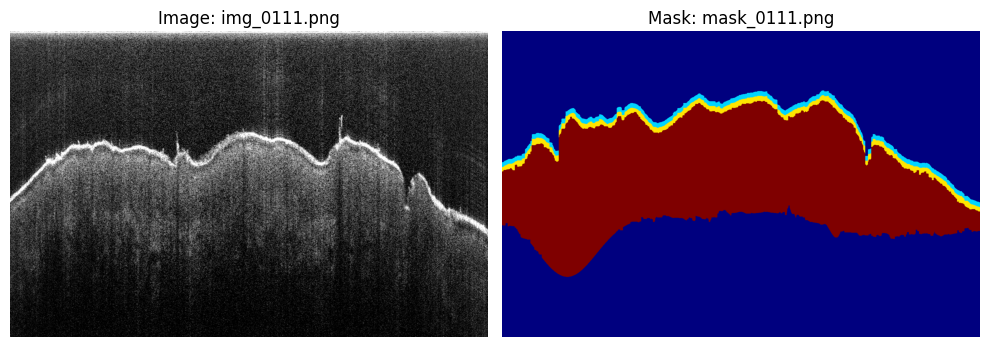

Unique values in mask: [1 2 3 4]
Model will actually use these values: [0 1 2 3]


In [ ]:
# CELL 7a - VISUAL CHECK OF IMAGE + MASK PAIRING
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Pick an index - using the train set to verify the split worked
i = 0

# Load for visualization
img_view = Image.open(img_train[i]).convert("RGB")
mask_view = Image.open(mask_train[i])

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_view)
plt.title(f"Image: {os.path.basename(img_train[i])}")
plt.axis("off")

plt.subplot(1, 2, 2)
# Using 'jet' helps distinguish the thin layers (SS/SC) better than 'gray'
plt.imshow(mask_view, cmap="jet")
plt.title(f"Mask: {os.path.basename(mask_train[i])}")
plt.axis("off")

plt.tight_layout()
plt.show()

# Print unique values to confirm class range (should be 1-4 or 0-3)
print("Unique values in mask:", np.unique(np.array(mask_view)))

# PROOF THE SHIFT WORKS
test_mask = np.array(mask_view)
shifted_mask = test_mask - 1
print("Model will actually use these values:", np.unique(shifted_mask))

In [ ]:
# CELL 7b (ALIGNED TRANSFORMS)
IMAGE_SIZE = 512

train_transform = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
    A.CLAHE(clip_limit=3.0, p=1.0),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transform = A.Compose([
    A.LongestMaxSize(max_size=IMAGE_SIZE),
    A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
    A.CLAHE(clip_limit=3.0, p=1.0),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

/tmp/ipykernel_1091/2774001158.py:6: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),
/tmp/ipykernel_1091/2774001158.py:16: UserWarning: Argument(s) 'value, mask_value' are not valid for transform PadIfNeeded
  A.PadIfNeeded(min_height=IMAGE_SIZE, min_width=IMAGE_SIZE, border_mode=cv2.BORDER_CONSTANT, value=0, mask_value=0),


In [ ]:
# CELL 7c - DATA LOADERS
from torch.utils.data import DataLoader

# --- DEFINE HYPERPARAMETERS ---
BATCH_SIZE = 8  # Use 8 or 16 for GPU. If it crashes, drop to 4.
EPOCHS = 40     # With 1200+ images, 40-50 epochs is usually plenty.

# Create Datasets
train_dataset = SkinDataset(img_train, mask_train, transform=train_transform)
val_dataset   = SkinDataset(img_val,   mask_val,   transform=val_transform)
test_dataset  = SkinDataset(img_test,  mask_test,  transform=val_transform)

# Create Loaders
# num_workers=2 helps speed up data loading on Colab GPUs
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ Loaders Created Successfully!")
print(f"Train: {len(train_dataset)} images ({len(train_loader)} batches)")
print(f"Val:   {len(val_dataset)} images")
print(f"Test:  {len(test_dataset)} images")

✅ Loaders Created Successfully!
Train: 890 images (112 batches)
Val:   191 images
Test:  191 images


In [ ]:
# CELL 8 - MODEL DEFINITION (U-Net++)
import torch
import torch.nn as nn
import segmentation_models_pytorch as smp

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 4
CLASSES = ['Background', 'SS', 'SC', 'DEJ']

# 1. MODEL DEFINITION: Unet++
model = smp.UnetPlusPlus(
    encoder_name='resnet34',
    encoder_weights='imagenet',
    in_channels=3,
    classes=NUM_CLASSES,
    # Adding attention and aux_params back for maximum power
    decoder_attention_type='scse',
    aux_params={
        "classes": NUM_CLASSES,
        "dropout": 0.4
    }
).to(DEVICE)

# 2. LOSS FUNCTIONS
class_weights = torch.tensor([0.5, 60.0, 60.0, 5.0]).to(DEVICE)
ce_criterion = nn.CrossEntropyLoss(weight=class_weights)
dice_loss = smp.losses.TverskyLoss(mode="multiclass", alpha=0.7, beta=0.3)

# 3. OPTIMIZER & SCHEDULER
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print(f"✅ U-Net++ initialized on {DEVICE}")

# 4. SCHEDULER
# Note: Ensure EPOCHS is defined in Cell 7c
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)

print(f"✅ Model (ResNet34 + Attention) initialized on: {DEVICE}")
if DEVICE == "cpu":
    print("⚠️ WARNING: No GPU found. Training will be extremely slow!")
print(f"✅ NUM_CLASSES set to {NUM_CLASSES}")
print(f"✅ Class Weights applied: {class_weights.cpu().numpy()}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

✅ U-Net++ initialized on cuda
✅ Model (ResNet34 + Attention) initialized on: cuda
✅ NUM_CLASSES set to 4
✅ Class Weights applied: [ 0.5 60.  60.   5. ]


In [ ]:
# CELL 8b - IoU Metric Function
import torch
import numpy as np

def compute_iou(outputs, masks, num_classes=4):
    # Convert model output probabilities to class predictions
    # outputs shape: [B, C, H, W] -> preds shape: [B, H, W]
    preds = torch.argmax(outputs, dim=1)

    ious = []
    preds = preds.view(-1)
    masks = masks.view(-1)

    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)

        # Use .long() to ensure bitwise operations work on tensors
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()

        if union == 0:
            # If the class isn't in the mask OR prediction, we don't penalize
            ious.append(float('nan'))
        else:
            ious.append(intersection / union)

    return ious

print("✅ IoU metric function defined.")

✅ IoU metric function defined.


In [ ]:
# CELL 9 - FINAL VERSION (FIXED FOR AUX_PARAMS & METRICS)
train_losses, val_losses, val_ious, val_ious_history = [], [], [], []
best_val_iou = 0.0
patience_counter = 0

print(f"Starting Training on {DEVICE}...")

for epoch in range(EPOCHS):
    # -------- TRAIN --------
    model.train()
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE).long()
        optimizer.zero_grad()

        # Handle auxiliary output tuple
        outputs = model(imgs)
        mask_preds = outputs[0]

        loss = ce_criterion(mask_preds, masks) + dice_loss(mask_preds, masks)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()
        epoch_loss += loss.item()

    # -------- VALIDATION --------
    model.eval()
    val_epoch_loss = 0
    batch_ious = []

    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE).long()

            mask_preds = model(imgs)[0]

            v_loss = ce_criterion(mask_preds, masks) + dice_loss(mask_preds, masks)
            val_epoch_loss += v_loss.item()

            # compute_iou returns a list [BG_iou, SS_iou, SC_iou, DEJ_iou]
            batch_ious.append(compute_iou(mask_preds, masks))

    # -------- METRICS CALCULATION (FIXED NAMES) --------
    avg_train = epoch_loss / len(train_loader)
    avg_val   = val_epoch_loss / len(val_loader)

    # Calculate per-class IoU average across all validation batches
    avg_iou_per_class = np.nanmean(batch_ious, axis=0)
    mean_iou = np.nanmean(avg_iou_per_class)

    # Append to history lists for plotting
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    val_ious.append(mean_iou)
    val_ious_history.append(avg_iou_per_class)

    # Save best model logic
    if mean_iou > best_val_iou:
        best_val_iou = mean_iou
        patience_counter = 0
        save_path = '/content/drive/MyDrive/new_2/best_oct_unet.pth'
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        torch.save(model.state_dict(), save_path)
        print(f"--> Best Model Saved at Epoch {epoch+1} (mIoU: {best_val_iou:.4f})")
    else:
        patience_counter += 1
        if patience_counter >= 12:
            print(f"Early stopping at epoch {epoch+1}")
            break

    scheduler.step()

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Loss (T/V): {avg_train:.3f}/{avg_val:.3f} | "
          f"SS IoU: {avg_iou_per_class[1]:.3f} | SC IoU: {avg_iou_per_class[2]:.3f} | "
          f"mIoU: {mean_iou:.4f}")

print("\n✅ Training Complete!")

Starting Training on cuda...
--> Best Model Saved at Epoch 1 (mIoU: 0.3555)
Epoch 1/40 | Loss (T/V): 1.679/1.449 | SS IoU: 0.019 | SC IoU: 0.076 | mIoU: 0.3555
--> Best Model Saved at Epoch 2 (mIoU: 0.4184)
Epoch 2/40 | Loss (T/V): 1.360/1.259 | SS IoU: 0.054 | SC IoU: 0.121 | mIoU: 0.4184
--> Best Model Saved at Epoch 3 (mIoU: 0.4738)
Epoch 3/40 | Loss (T/V): 1.241/1.213 | SS IoU: 0.069 | SC IoU: 0.165 | mIoU: 0.4738
--> Best Model Saved at Epoch 4 (mIoU: 0.4924)
Epoch 4/40 | Loss (T/V): 1.155/1.117 | SS IoU: 0.114 | SC IoU: 0.170 | mIoU: 0.4924
Epoch 5/40 | Loss (T/V): 1.075/1.061 | SS IoU: 0.167 | SC IoU: 0.165 | mIoU: 0.4905
--> Best Model Saved at Epoch 6 (mIoU: 0.5420)
Epoch 6/40 | Loss (T/V): 0.999/0.964 | SS IoU: 0.171 | SC IoU: 0.258 | mIoU: 0.5420
--> Best Model Saved at Epoch 7 (mIoU: 0.5607)
Epoch 7/40 | Loss (T/V): 0.917/0.875 | SS IoU: 0.217 | SC IoU: 0.257 | mIoU: 0.5607
--> Best Model Saved at Epoch 8 (mIoU: 0.5932)
Epoch 8/40 | Loss (T/V): 0.801/0.801 | SS IoU: 0.306 |

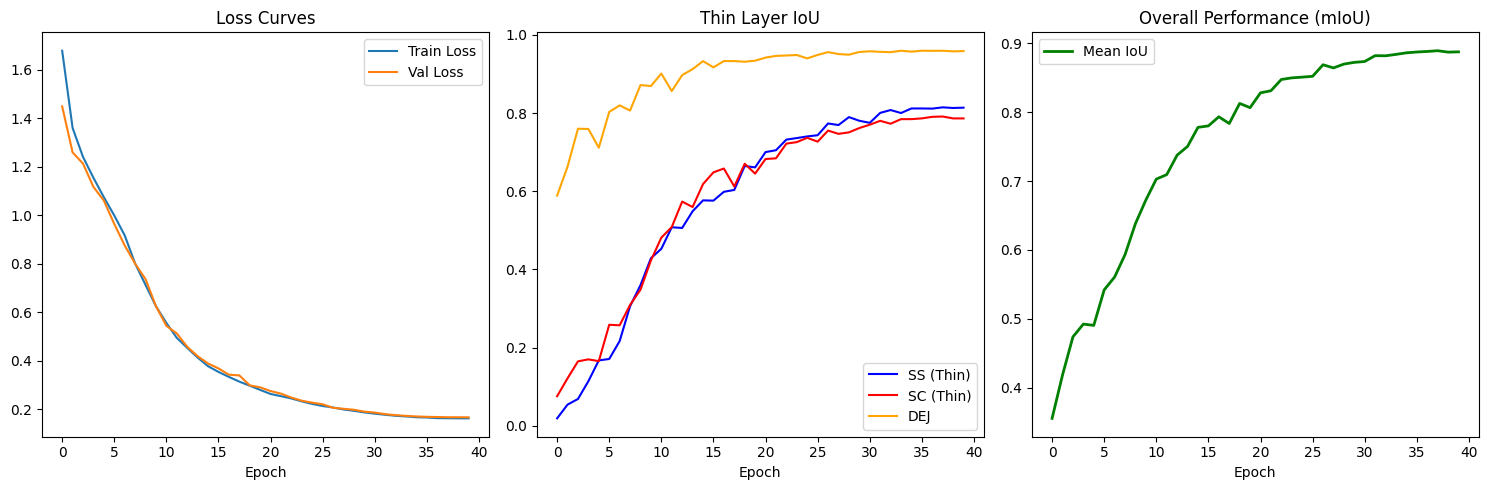

In [ ]:
# CELL 10 - Plotting per-class performance (FIXED)
import matplotlib.pyplot as plt
import numpy as np

# Ensure history exists before plotting
if 'val_ious_history' in locals() and len(val_ious_history) > 0:
    ious_array = np.array(val_ious_history)

    plt.figure(figsize=(15, 5))

    # Subplot 1: Losses
    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.legend()

    # Subplot 2: Per-Class IoU (Thin Layers Focus)
    plt.subplot(1, 3, 2)
    plt.plot(ious_array[:, 1], label='SS (Thin)', color='blue')
    plt.plot(ious_array[:, 2], label='SC (Thin)', color='red')
    plt.plot(ious_array[:, 3], label='DEJ', color='orange')
    plt.title('Thin Layer IoU')
    plt.xlabel('Epoch')
    plt.legend()

    # Subplot 3: Mean IoU
    plt.subplot(1, 3, 3)
    plt.plot(val_ious, label='Mean IoU', color='green', linewidth=2)
    plt.title('Overall Performance (mIoU)')
    plt.xlabel('Epoch')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("❌ Error: No training history found. Please run the training cell (Cell 9) first.")

In [ ]:
# CELL 11 - FINAL EVALUATION (All Metrics: IoU, Dice/F-Score, AUC, MSE, RMSE, MAE, R2)
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, mean_squared_error, mean_absolute_error, r2_score
import seaborn as sns

# Load the best U-Net++ weights
model.load_state_dict(torch.load('/content/drive/MyDrive/new_2/best_oct_unetplusplus.pth'))
model.eval()

# Storage
all_ious, all_dice, all_sen, all_spe, all_pre, pixel_acc = [], [], [], [], [], []
all_preds, all_masks, all_probs = [], [], []

print("Running deep evaluation on U-Net++ test set...")

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        # U-Net++ with aux_params returns a tuple (main_mask, auxiliary_mask)
        outputs = model(imgs)
        mask_logits = outputs[0] if isinstance(outputs, (tuple, list)) else outputs

        probs = torch.softmax(mask_logits, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Basic Metrics
        pixel_acc.append((preds == masks).float().mean().item())
        p_flat = preds.cpu().numpy().flatten()
        g_flat = masks.cpu().numpy().flatten()

        iou_pc, dice_pc, sen_pc, spe_pc, pre_pc = [], [], [], [], []

        for c in range(NUM_CLASSES):
            tp = np.sum((p_flat == c) & (g_flat == c))
            fp = np.sum((p_flat == c) & (g_flat != c))
            fn = np.sum((p_flat != c) & (g_flat == c))
            tn = np.sum((p_flat != c) & (g_flat != c))

            iou_pc.append(tp / (tp + fp + fn + 1e-6))
            dice_pc.append((2*tp) / (2*tp + fp + fn + 1e-6))
            sen_pc.append(tp / (tp + fn + 1e-6))
            spe_pc.append(tn / (tn + fp + 1e-6))
            pre_pc.append(tp / (tp + fp + 1e-6))

        all_ious.append(iou_pc)
        all_dice.append(dice_pc)
        all_sen.append(sen_pc)
        all_spe.append(spe_pc)
        all_pre.append(pre_pc)

        # Store for advanced metrics
        all_preds.append(p_flat)
        all_masks.append(g_flat)
        all_probs.append(probs.cpu().numpy().reshape(-1, NUM_CLASSES))

# Flatten for global metrics
y_true = np.concatenate(all_masks)
y_pred = np.concatenate(all_preds)
y_probs = np.concatenate(all_probs)

# Regression Metrics
y_true_oh = np.eye(NUM_CLASSES)[y_true]
mse = mean_squared_error(y_true_oh, y_probs)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_true_oh, y_probs)
r2 = r2_score(y_true_oh, y_probs)

# Print Results
print('\n' + '='*50)
print('          U-NET++ COMPREHENSIVE TEST METRICS')
print('='*50)
print(f'Mean Pixel Accuracy:  {np.mean(pixel_acc)*100:.2f}%')
print(f'Overall Mean IoU:     {np.mean(all_ious):.4f}')
print(f'Overall Mean Dice/F1: {np.mean(all_dice):.4f}')
print(f'Overall Sensitivity:  {np.mean(all_sen):.4f}')
print(f'Overall Specificity:  {np.mean(all_spe):.4f}')
print(f'Overall Precision:    {np.mean(all_pre):.4f}')
print('-'*50)
print(f'MSE (Error):          {mse:.4f}')
print(f'RMSE (Error):         {rmse:.4f}')
print(f'MAE (Error):          {mae:.4f}')
print(f'R-Squared:            {r2:.4f}')
print('-'*50)

for c, name in enumerate(CLASSES):
    print(f'{name:12s} -> IoU: {np.mean(np.array(all_ious)[:,c]):.3f} | '
          f'Dice: {np.mean(np.array(all_dice)[:,c]):.3f} | '
          f'Sen: {np.mean(np.array(all_sen)[:,c]):.3f} | '
          f'Spe: {np.mean(np.array(all_spe)[:,c]):.3f} | '
          f'Pre: {np.mean(np.array(all_pre)[:,c]):.3f}')

Running deep evaluation on U-Net++ test set...

          U-NET++ COMPREHENSIVE TEST METRICS
Mean Pixel Accuracy:  98.99%
Overall Mean IoU:     0.8860
Overall Mean Dice/F1: 0.9372
Overall Sensitivity:  0.9670
Overall Specificity:  0.9962
Overall Precision:    0.9108
--------------------------------------------------
MSE (Error):          0.3730
RMSE (Error):         0.6107
MAE (Error):          0.3750
R-Squared:            -12.5743
--------------------------------------------------
Background   -> IoU: 0.991 | Dice: 0.995 | Sen: 0.992 | Spe: 0.995 | Pre: 0.999
SS           -> IoU: 0.805 | Dice: 0.892 | Sen: 0.947 | Spe: 0.998 | Pre: 0.843
SC           -> IoU: 0.791 | Dice: 0.883 | Sen: 0.944 | Spe: 0.998 | Pre: 0.829
DEJ          -> IoU: 0.957 | Dice: 0.978 | Sen: 0.985 | Spe: 0.994 | Pre: 0.972


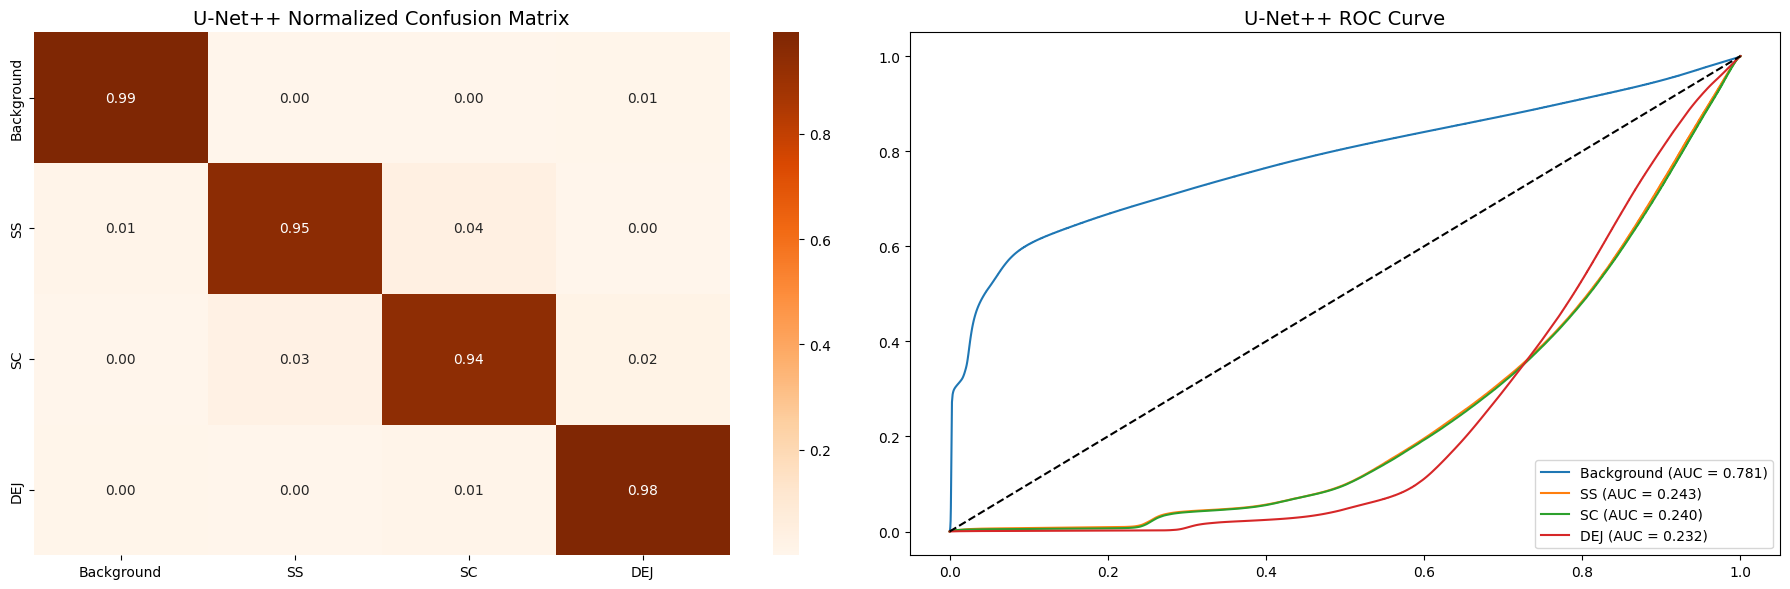

In [ ]:
# CELL 11b - Visual Plots for U-Net++
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 6))

# 1. Confusion Matrix
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Oranges', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('U-Net++ Normalized Confusion Matrix', fontsize=14)

# 2. ROC Curve
plt.subplot(1, 2, 2)
for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true == i, y_probs[:, i])
    auc_score = roc_auc_score(y_true == i, y_probs[:, i])
    plt.plot(fpr, tpr, label=f'{CLASSES[i]} (AUC = {auc_score:.3f})')

plt.plot([0, 1], [0, 1], color='black', linestyle='--')
plt.title('U-Net++ ROC Curve', fontsize=14)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

✅ Random prediction saved to: /content/drive/MyDrive/new_2/unetplusplus_idx_58.png


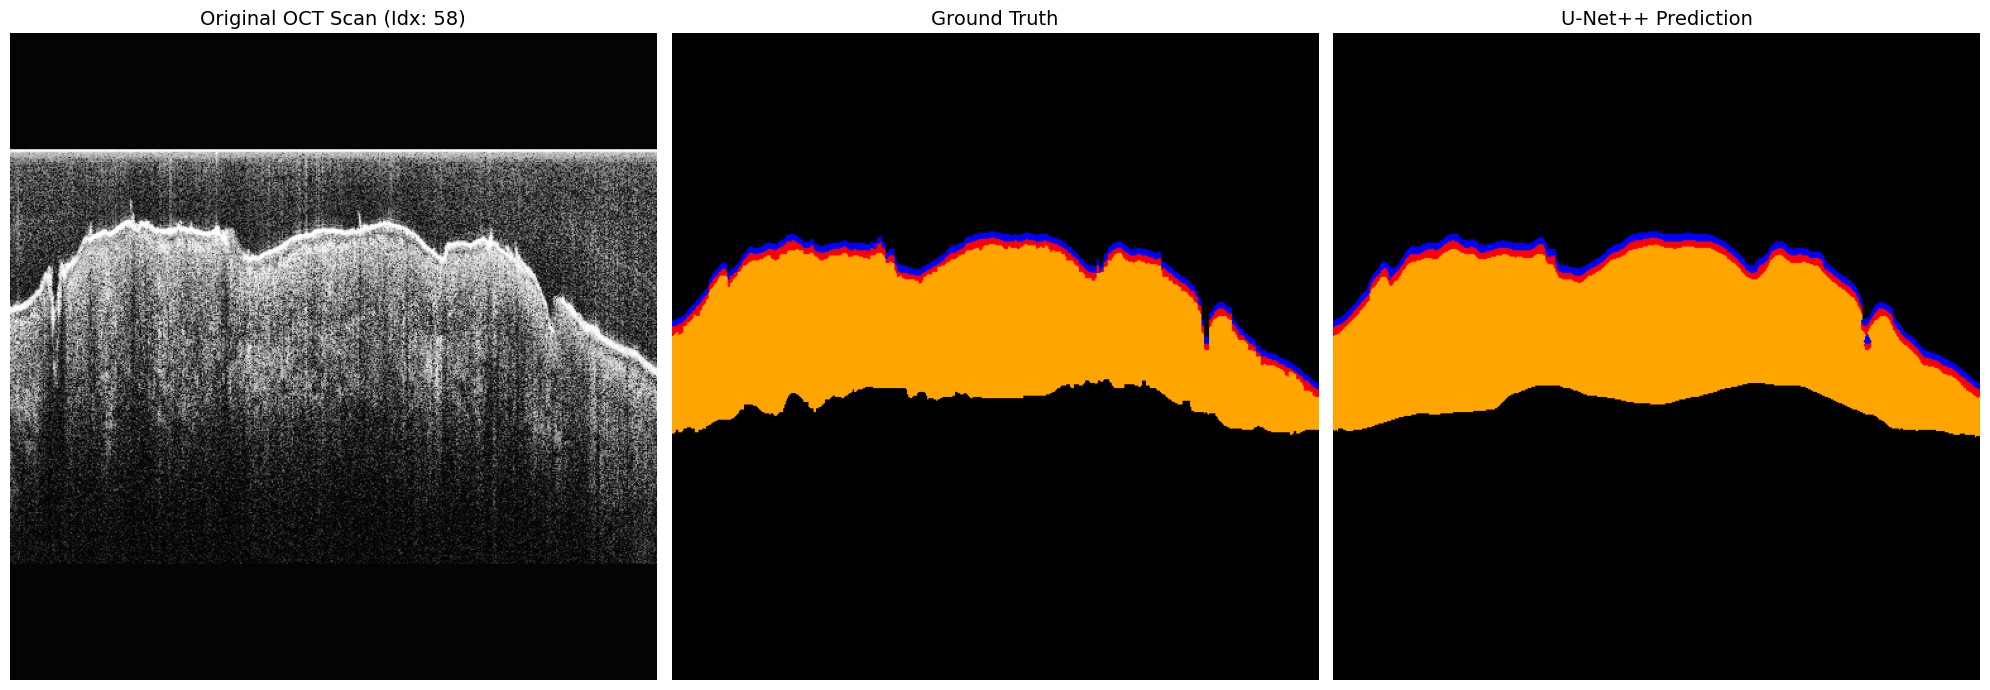

In [ ]:
# CELL 12 - U-Net++ Randomized Visualizer
import random

model.eval()

# 1. Pick a random test sample
idx = random.randint(0, len(test_dataset) - 1)
img, mask = test_dataset[idx]
img_tensor = img.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    outputs = model(img_tensor)
    mask_logits = outputs[0] if isinstance(outputs, (tuple, list)) else outputs
preds = torch.argmax(mask_logits, dim=1).squeeze(0).cpu().numpy()

# 2. Un-normalize
img_np = img.permute(1, 2, 0).numpy()
mean, std = np.array([0.485, 0.456, 0.406]), np.array([0.229, 0.224, 0.225])
img_uint8 = (np.clip((img_np * std + mean), 0, 1) * 255).astype(np.uint8)

# 3. Solid Color Mapping
solid_colors = np.array([[0,0,0], [0,0,255], [255,0,0], [255,165,0]], dtype=np.uint8)
gt_rgb = solid_colors[mask.numpy()]
pred_rgb = solid_colors[preds]

# 4. Display
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(img_uint8)
axes[0].set_title(f'Original OCT Scan (Idx: {idx})', fontsize=14)
axes[1].imshow(gt_rgb)
axes[1].set_title('Ground Truth', fontsize=14)
axes[2].imshow(pred_rgb)
axes[2].set_title(f'U-Net++ Prediction', fontsize=14)

for ax in axes: ax.axis('off')
plt.tight_layout()

# Save unique file
save_path = f'/content/drive/MyDrive/new_2/unetplusplus_idx_{idx}.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ Random prediction saved to: {save_path}")
plt.show()

In [ ]:
!pip install segmentation-models-pytorch
!pip install thop

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 3.7 MB/s eta 0:00:00


In [ ]:
!pip install thop

import segmentation_models_pytorch as smp
import torch
import time
from thop import profile

# Just recreate the architecture - no training needed
model = smp.DeepLabV3Plus(
    encoder_name="resnet50",
    encoder_weights=None,
    in_channels=3,
    classes=4
)

model.eval()
model = model.to('cpu')

# 1. Parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Total Parameters: {total_params:,}")

# 2. GFLOPs
dummy_input = torch.randn(1, 3, 512, 512)
flops, params = profile(model, inputs=(dummy_input,), verbose=False)
print(f"GFLOPs: {flops/1e9:.2f}")

# 3. Latency
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy_input)
    start = time.time()
    for _ in range(100):
        _ = model(dummy_input)
    latency = (time.time() - start) / 100 * 1000
print(f"Average Latency: {latency:.2f} ms")

Total Parameters: 26,678,356
GFLOPs: 36.93
Average Latency: 1844.73 ms
